In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager
from auditoryforage.utils import plot_AF_episode

# Train one agent for a single environment

In [19]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 50) loaded.
Fetching the most trained agent so far (epoch 50).
Agent (seed 0) was trained for 50 epochs, RL optimality 99.01%.


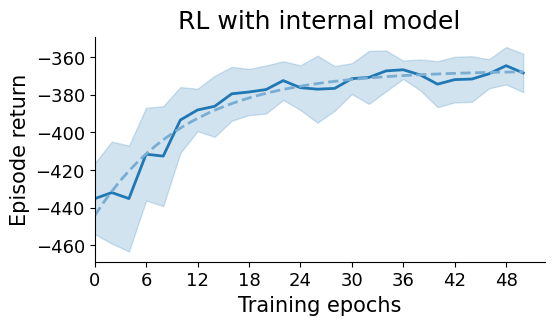

In [20]:
env_param = [-3.0, 16.0, 20, 9, -8, -4]
num_epochs = 50

#Lokesh - added this for recent SB3
seed = 100

#Lokesh - added this for recent SB3
agent = manager.train_agent(env_param, num_epochs=num_epochs)
# agent = manager.train_agent(env_param, seed=seed, num_epochs=num_epochs)

agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

{'experiment': {'prob_01': 0.5,
  'no_signal_nodes': 4,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1},
 'agent': {'lick_cost': -3.0,
  'food_reward': 16.0,
  'attention_cost_coeff': 20,
  'attention_cost_temp': 9,
  'penalty_cost': -8,
  'iti_cost': -4,
  'no_attention_modes': 3}}

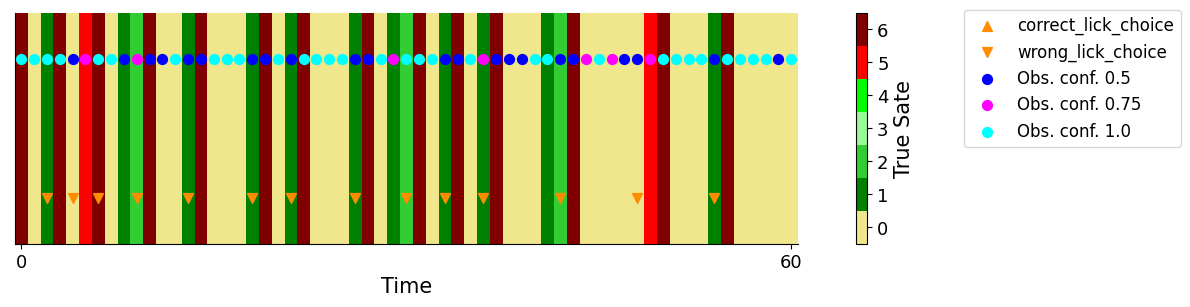

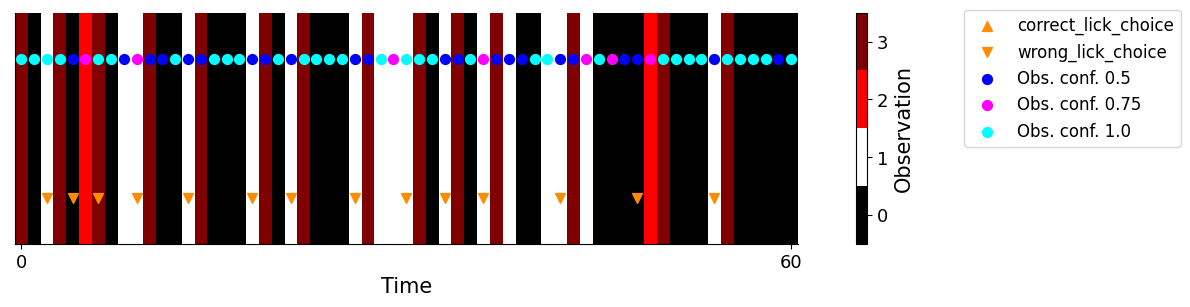

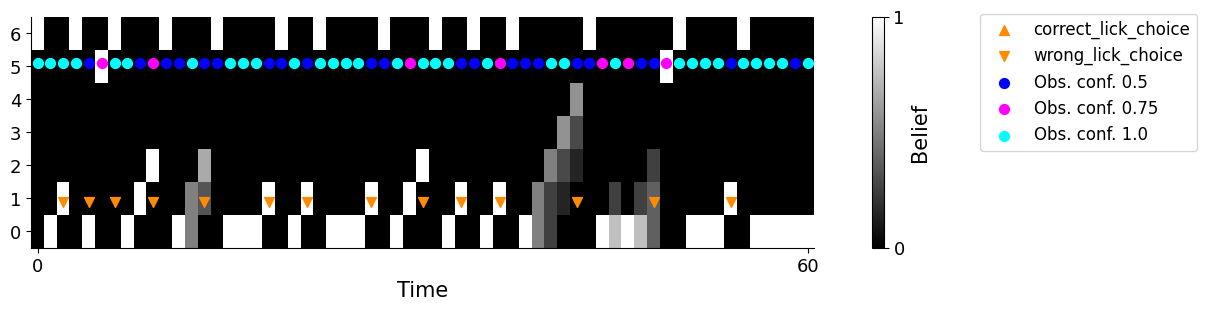

In [21]:
from auditoryforage.AF_env import AuditoryForaging

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'experiment': {'prob_01': 0.5},'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, num_steps=60, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env)

env.spec



In [22]:
# agent1, fig = manager.inspect_agent(env_param, figsize=(5, 2.5), seed = 0)
# agent2, fig = manager.inspect_agent(env_param, figsize=(5, 2.5), seed = 1)
# agent3, fig = manager.inspect_agent(env_param, figsize=(5, 2.5), seed = 2)

# beliefs = episode['beliefs']

# action_distributions1 = agent1.agent_action_distribution(beliefs)
# action_distributions2 = agent2.agent_action_distribution(beliefs)
# action_distributions3 = agent3.agent_action_distribution(beliefs)

Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.


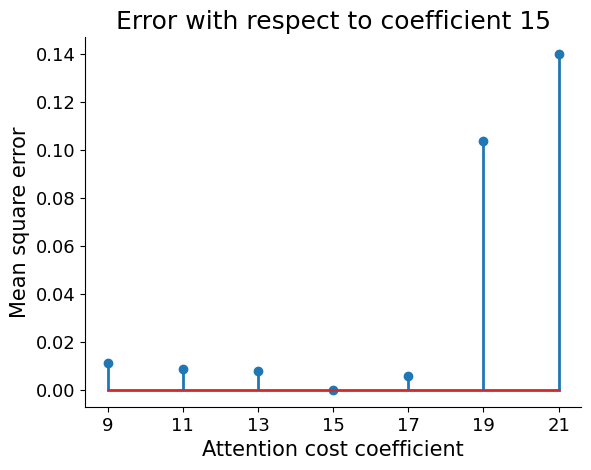

In [27]:
env_param = [-3.0, 12.0, 15, 10, -8, -4]
beliefs = episode['beliefs']

attention_cost_coeff_list = [9, 11, 13, 15, 17, 19, 21] # attention_cost_coeff
replace_index = 2
reference_index = 3

num_epochs = 50
agents_list = []
action_distributions_list = []

for attention_cost_coeff in attention_cost_coeff_list:
    env_param_temp = env_param[:replace_index]+[attention_cost_coeff]+env_param[replace_index+1:]
    agent = manager.train_agent(env_param_temp, num_epochs=num_epochs)
    agents_list.append(agent)
    action_distributions_list.append(agent.agent_action_distribution(beliefs))


reference_dists = np.array(action_distributions_list[reference_index])
difference = []
for action_distributions in action_distributions_list:
    difference.append(np.sum((np.array(action_distributions)- reference_dists)**2)/reference_dists.size)

plt.figure()
plt.stem(difference)
plt.xlabel('Attention cost coefficient')
plt.ylabel('Mean square error')
plt.xticks(range(len(attention_cost_coeff_list)), ['{:g}'.format(v) for v in attention_cost_coeff_list])
plt.title(f'Error with respect to coefficient {env_param[replace_index]}')
plt.show()

Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.
Checkpoint (epoch 50) loaded.


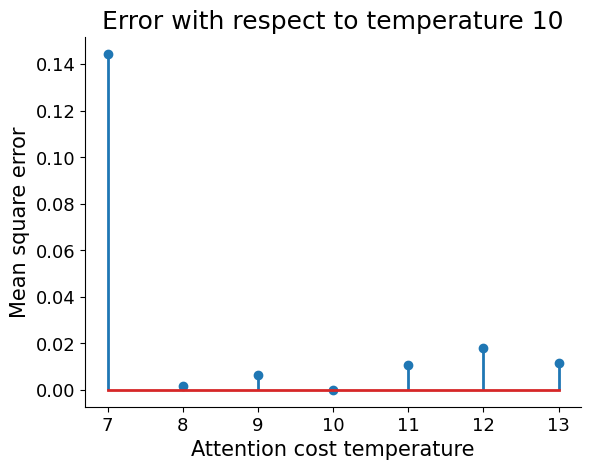

In [28]:
env_param = [-3.0, 12.0, 15, 10, -8, -4]
beliefs = episode['beliefs']

attention_cost_temp_list = [7, 8, 9, 10, 11, 12, 13] # attention_cost_temp
replace_index = 3
reference_index = 3

num_epochs = 50
agents_list = []
action_distributions_list = []

for attention_cost_coeff in attention_cost_coeff_list:
    env_param_temp = env_param[:replace_index]+[attention_cost_coeff]+env_param[replace_index+1:]
    agent = manager.train_agent(env_param_temp, num_epochs=num_epochs)
    agents_list.append(agent)
    action_distributions_list.append(agent.agent_action_distribution(beliefs))


reference_dists = np.array(action_distributions_list[reference_index])
difference = []
for action_distributions in action_distributions_list:
    difference.append(np.sum((np.array(action_distributions)- reference_dists)**2)/reference_dists.size)

plt.figure()
plt.stem(difference)
plt.xlabel('Attention cost temperature')
plt.ylabel('Mean square error')
plt.title(f'Error with respect to temperature {env_param[replace_index]}')
plt.xticks(range(len(attention_cost_coeff_list)), ['{:g}'.format(v) for v in attention_cost_temp_list])
plt.show()